# Module 3.5 — Multigrid Methods

**The most important linear solver acceleration technique in CFD.**

## The one-sentence analogy

Imagine smoothing wrinkles out of a bedsheet by patting it down. A small wrinkle (high-frequency error) flattens in one pat. But one giant fold spanning the whole sheet (low-frequency error) barely moves no matter how many times you pat — your hand only feels *locally flat* fabric. **Step back** and look at the sheet from across the room: that same giant fold now looks like a small local wrinkle, and a single pat (at this lower resolution) flattens it.

**That's multigrid:** smooth small-scale error on the fine grid (cheap), step back to a coarse grid where the big fold now looks like a small wrinkle, smooth it there (cheap), then return and clean up.

## Why this matters

Every incompressible N-S simulation must solve the pressure Poisson equation at every time step. On a $100 \times 100$ grid, Gauss-Seidel needs thousands of iterations to converge. Multigrid needs ~20, **regardless of grid size**. The speedup is not linear — it grows with the mesh.

**Roadmap:**
1. What we're doing now — Jacobi/Gauss-Seidel as local smoothing
2. What's wrong with it — frequency analysis, $O(N^2)$ stalling
3. The fix — coarse-grid correction (the "step back" idea)
4. Transfer operators — restriction and prolongation
5. The V-cycle — recursive multigrid
6. Convergence: $O(N)$ — grid-independent rate
7. Implementation and demonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. What We're Doing Now: Local Smoothing

### The update rule

Solving $-\dfrac{d^2u}{dx^2} = f$ with Gauss-Seidel, each sweep updates every point to:

$$u_i^{\text{new}} = \frac{u_{i-1} + u_{i+1} - f_i\Delta x^2}{2}$$

This is a **local weighted average of neighbours** — nearly identical to one explicit step of the heat/diffusion equation. Jacobi is the same idea but uses old values for *both* neighbours.

### Analogy: passing numbers down a line of people

Picture $N$ people standing in a line, each holding a number. Every round, everyone simultaneously sets their number to the average of their two neighbours.

- **One person holds 100, everyone else holds 0** (a sharp local spike — *high-frequency error*):
  Round 1 → spreads to 50/50 with neighbours. Round 2 → spreads further. Within ~5 rounds the spike is gone. **Local features die almost instantly.**

- **Person 1 holds 0, person $N$ holds 100, smooth ramp in between** (*low-frequency error*):
  Every person's neighbours already hold almost the same number as them, so averaging changes almost nothing. It takes $\sim N^2$ rounds for information from one end to reach the other. **Global, smooth features barely move.**

This is exactly diffusion: local bumps equilibrate in $O(1)$ steps, but a domain-spanning gradient takes $O(L^2/\nu) = O(N^2)$ steps.

### The math: amplification factor $G(k)$

Decompose the error into Fourier modes $e_i = \sin(k\pi x_i)$, $k=1,\dots,N-1$. One Gauss-Seidel/Jacobi sweep multiplies mode $k$ by:

$$G(k) = \cos\left(\frac{k\pi}{N}\right)$$

| Mode | Meaning | $G(k)$ | Behaviour |
|---|---|---|---|
| $k \approx N$ (alternates sign every cell) | high-frequency, scale $\Delta x$ | $\lvert G\rvert \to 0$ | ✅ killed in a few sweeps |
| $k \approx 1$ (one smooth hump over the whole domain) | low-frequency, scale $L$ | $G \approx 1 - \dfrac{\pi^2}{2N^2} \approx 1$ | ❌ survives thousands of sweeps |

Let's *see* this before going further.

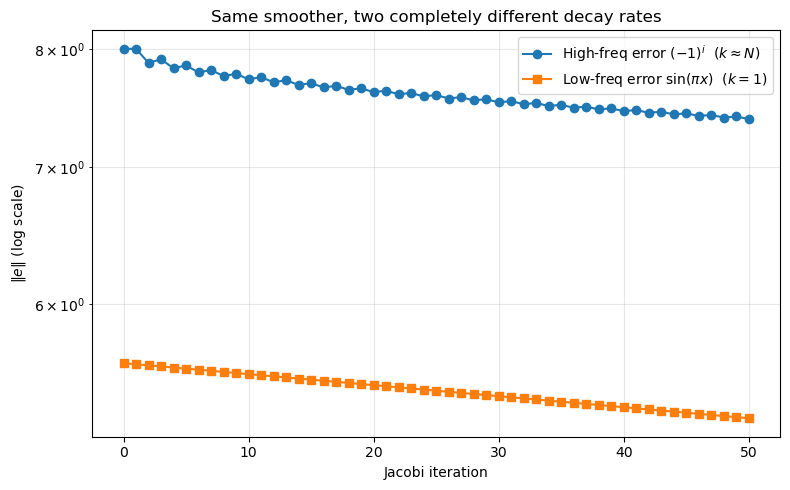

High-freq: ||e|| dropped by factor 1.1e+00 in 50 iters
Low-freq : ||e|| dropped by factor 1.064 in 50 iters
Predicted G(1) = cos(π/64) = 0.998795  ->  G(1)^50 = 0.942


In [2]:
# ── Demo 1: frequency-dependent decay, G(k) = cos(kπ/N) ─────────────────────
N = 64
x = np.linspace(0, 1, N)

e_high = (-1.0) ** np.arange(N)        # k ≈ N : alternating ±1 (high-frequency)
e_low  = np.sin(np.pi * x)             # k = 1 : one smooth hump (low-frequency)

def jacobi_smooth(e, n_iter):
    e = e.copy()
    norms = [np.linalg.norm(e)]
    for _ in range(n_iter):
        e_new = e.copy()
        e_new[1:-1] = 0.5 * (e[:-2] + e[2:])
        e = e_new
        norms.append(np.linalg.norm(e))
    return norms

n_iter = 50
norms_high = jacobi_smooth(e_high, n_iter)
norms_low  = jacobi_smooth(e_low,  n_iter)

plt.figure(figsize=(8, 5))
plt.semilogy(norms_high, 'o-', label=r'High-freq error $(-1)^i$  ($k\approx N$)')
plt.semilogy(norms_low,  's-', label=r'Low-freq error $\sin(\pi x)$  ($k=1$)')
plt.xlabel('Jacobi iteration'); plt.ylabel(r'$\|e\|$ (log scale)')
plt.title('Same smoother, two completely different decay rates')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"High-freq: ||e|| dropped by factor {norms_high[0]/norms_high[-1]:.1e} in {n_iter} iters")
print(f"Low-freq : ||e|| dropped by factor {norms_low[0]/norms_low[-1]:.3f} in {n_iter} iters")
print(f"Predicted G(1) = cos(π/{N}) = {np.cos(np.pi/N):.6f}  ->  G(1)^{n_iter} = {np.cos(np.pi/N)**n_iter:.3f}")

## 2. What's Wrong: $O(N^2)$ Stalling

The demo above is the whole story. After a handful of sweeps:

- All high-frequency content → gone
- What's left is **purely smooth, low-frequency error** with $G \approx 1 - \dfrac{\pi^2}{2N^2}$

**Iterations needed to reduce error by a fixed factor:**

$$\text{iters} \sim \frac{1}{1-G(1)} \sim \frac{2N^2}{\pi^2} = O(N^2)$$

| Grid | $O(N^2)$ iterations (relative) |
|---|---|
| $N=64$   | $1\times$  |
| $N=128$  | $4\times$  |
| $N=256$  | $16\times$ |

Refine the mesh $4\times$ (common when checking grid-independence) → **16× more iterations**, and each iteration costs more too. This is the wall you hit in Module 2.14: the residual curve flattens and nothing happens for thousands of iterations.

## 3. The Fix: Coarse-Grid Correction

### "Step back" analogy

Back to the bedsheet: that one giant fold spans the whole sheet — *up close* your hand only feels flat fabric, it can't even tell the fold is there. **Step back** (view the sheet at lower resolution) and that same fold now looks like a sharp local wrinkle — your hand flattens it in one pat.

### The grid-resolution version

Take a smooth error with $k=4$ periods over the domain:

- **Fine grid** ($N=64$): $64/4=16$ cells per period $\;\Rightarrow\; G(4)=\cos(4\pi/64)\approx 0.988$ (slow)
- **Coarse grid** ($N=32$, every other point): the *same* 4 periods now span only $32/4=8$ cells per period $\;\Rightarrow\; G(4)=\cos(4\pi/32)\approx 0.952$ (faster)

The wavenumber $k$ hasn't changed — but relative to the *new, larger* grid spacing $2\Delta x$, the same error is **twice as oscillatory**. Halve the resolution enough times, and any smooth error eventually looks like the high-frequency case from Demo 1, where $G\to 0$.

### The two-level algorithm

$$
\begin{aligned}
&\textbf{1. Pre-smooth: } && u^h \leftarrow \text{GS}^{\nu_1}(u^h, f^h) &&\text{kill high-freq error}\\
&\textbf{2. Residual: } && r^h = f^h - A^h u^h &&\text{how far from solved?}\\
&\textbf{3. Restrict: } && r^{2h} = R\,r^h &&\text{view error on coarse grid}\\
&\textbf{4. Coarse solve: } && A^{2h} e^{2h} = r^{2h} &&\text{now high-freq → fast}\\
&\textbf{5. Prolongate: } && e^h = P\,e^{2h} &&\text{interpolate correction back}\\
&\textbf{6. Correct: } && u^h \leftarrow u^h + e^h\\
&\textbf{7. Post-smooth: } && u^h \leftarrow \text{GS}^{\nu_2}(u^h, f^h) &&\text{clean interpolation artefacts}
\end{aligned}
$$

Let's see the "step back" effect numerically before implementing the full thing.

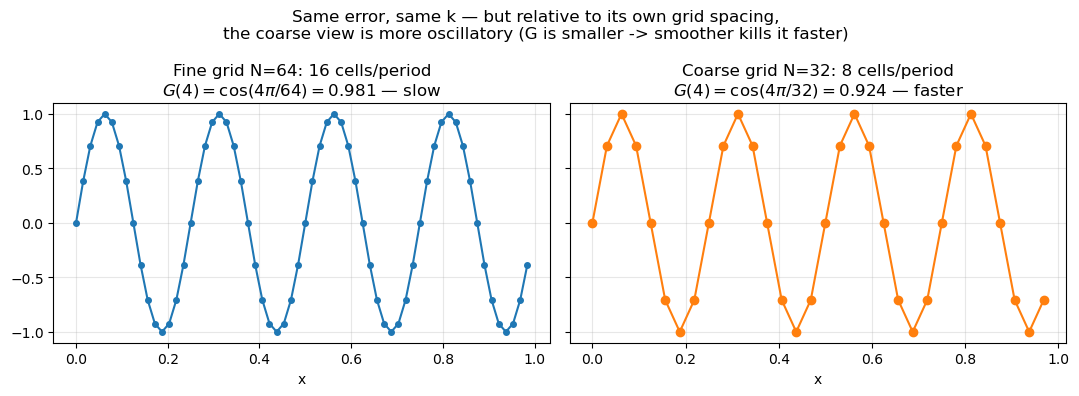

In [3]:
# ── Demo 2: same error, fine grid vs coarse grid ────────────────────────────
N_fine, N_coarse, k = 64, 32, 4

x_fine   = np.linspace(0, 1, N_fine,   endpoint=False)
x_coarse = np.linspace(0, 1, N_coarse, endpoint=False)

e_fine   = np.sin(2*np.pi*k*x_fine)
e_coarse = e_fine[::2]                       # restriction: every other point

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax[0].plot(x_fine, e_fine, 'o-', ms=4)
ax[0].set_title(f'Fine grid N={N_fine}: {N_fine//k} cells/period\n'
                 f'$G({k})=\\cos({k}\\pi/{N_fine})={np.cos(k*np.pi/N_fine):.3f}$ — slow')
ax[1].plot(x_coarse, e_coarse, 'o-', ms=6, color='C1')
ax[1].set_title(f'Coarse grid N={N_coarse}: {N_coarse//k} cells/period\n'
                 f'$G({k})=\\cos({k}\\pi/{N_coarse})={np.cos(k*np.pi/N_coarse):.3f}$ — faster')
for a in ax:
    a.grid(True, alpha=0.3); a.set_xlabel('x')
plt.suptitle('Same error, same k — but relative to its own grid spacing,\n'
              'the coarse view is more oscillatory (G is smaller -> smoother kills it faster)')
plt.tight_layout(); plt.show()

## 4. Transfer Operators: Moving Between Grids

We now have two grids talking to each other. We need a precise way to move information **down** (fine → coarse) and **up** (coarse → fine).

### Restriction $R$: fine → coarse (sending the residual down)

**Analogy:** Imagine you're translating a detailed weather map (one reading per km) into a coarse map (one reading per 2 km). You wouldn't just throw away every other reading (that's "injection" — risky, it can miss a spike sitting exactly on a discarded point). Instead, each coarse value is a **weighted average of itself and its two fine neighbours** — a "majority vote weighted by closeness." This is **full-weighting**:

$$r^{2h}_i = \frac{1}{4}r^h_{2i-1} + \frac{1}{2}r^h_{2i} + \frac{1}{4}r^h_{2i+1}$$

The coarse-grid point $i$ keeps half its own value and borrows a quarter from each neighbour — nothing is silently dropped.

### Prolongation $P$: coarse → fine (sending the correction back up)

**Analogy:** Now go the other way — you have a correction computed on the coarse map and need to paint it back onto the detailed map. The points that exist on *both* grids just copy their value across. The *new* points (that only exist on the fine grid) get the **average of their two coarse-grid neighbours** — simple linear interpolation:

$$e^h_{2i} = e^{2h}_i \qquad\text{(point exists on both grids — direct copy)}$$

$$e^h_{2i+1} = \frac{1}{2}\left(e^{2h}_i + e^{2h}_{i+1}\right) \qquad\text{(new fine point — interpolate)}$$

These two operators ($R$ and $P$) are exact transposes of each other (up to a constant) — a nice symmetry that keeps multigrid mathematically well-behaved.

## 5. The V-Cycle: Recursive Multigrid

A **two-grid** method (Section 3) only has one coarse level. But why stop there? The coarse-grid problem $A^{2h}e^{2h}=r^{2h}$ is *itself* a Poisson-like problem — so apply the **same trick again**: smooth it, restrict to $4h$, solve there, prolongate back. Recurse all the way down to a grid so coarse (e.g. 1–3 points) that an exact solve is nearly free.

This recursive structure traces out a **"V" shape** across grid levels:

```
Level 0 (h)    u ──smooth──→ residual ──┐                later: ┌──prolongate──→ +e ──smooth──→ done
                                          ↓ restrict                              ↑ correct
Level 1 (2h)         u=0 ──smooth──→ residual ──┐              ┌──prolongate──→ +e ──smooth──→ done
                                                  ↓ restrict      ↑ correct
Level 2 (4h)               u=0 ──smooth──→ residual ──┐       ┌─→ +e ──smooth──→ done
                                                        ↓ restrict   ↑ correct
Level 3 (8h, coarsest)                       u=0 ──── exact solve ──┘
```

Going down the left side of the V: **restrict**. At the bottom: **exact solve** (cheap — tiny grid). Going up the right side: **prolongate + correct + smooth**.

### The recursive algorithm

$$
\text{V-cycle}(u^h, f^h) =
\begin{cases}
\text{solve } A^h u^h = f^h \text{ exactly} & \text{if } h \text{ is coarsest grid} \\[6pt]
\begin{aligned}
&u^h \leftarrow \text{smooth}^{\nu_1}(u^h, f^h) \\
&r^h = f^h - A^h u^h \\
&r^{2h} = R\,r^h \\
&e^{2h} = \text{V-cycle}(0,\, r^{2h}) \quad\leftarrow \text{recursive call!}\\
&u^h \leftarrow u^h + P\,e^{2h} \\
&u^h \leftarrow \text{smooth}^{\nu_2}(u^h, f^h)
\end{aligned}
& \text{otherwise}
\end{cases}
$$

One V-cycle is one call to this function. In practice you call it ~10-20 times until the residual is small enough.

## 6. Convergence: $O(N)$ — Grid-Independent

This is the payoff. Let's count the total work for **one V-cycle** on a fine grid of $N$ points:

$$\underbrace{N}_{\text{level }h} + \underbrace{N/2}_{\text{level }2h} + \underbrace{N/4}_{\text{level }4h} + \cdots \approx 2N = O(N)$$

A geometric series — even with infinitely many levels, the total cost is bounded by **twice the cost of smoothing the finest grid once**. Each level is 4× cheaper (1D: 2× fewer points) than the one above, so the sum converges.

Crucially, because *every* level — fine or coarse — only ever has to remove the "locally-wiggly-relative-to-its-own-grid" part of the error (Section 3), the **convergence factor per V-cycle is a constant** $\rho \approx 0.1\text{–}0.2$, independent of $N$. To reduce the error by a fixed factor $\varepsilon$, you need $\log(1/\varepsilon)/\log(1/\rho) \approx$ a handful of cycles — **always**, whether $N=64$ or $N=10^6$.

| Method | Cost per iteration/cycle | Iterations to converge | **Total cost** |
|---|---|---|---|
| Gauss-Seidel | $O(N)$ | $O(N^2)$ | $O(N^3)$ |
| Multigrid V-cycle | $O(N)$ | $O(1)$ (grid-independent!) | $O(N)$ |

Going from $O(N^3)$ to $O(N)$ is the difference between a pressure solve that takes seconds vs. one that takes hours on a fine 3D mesh.

## 7. Implementation

Below is a complete 1D V-cycle: `gauss_seidel` (the smoother from Section 1), `restrict_fw` and `prolongate_linear` (exactly the formulas from Section 4), and `v_cycle` (the recursive algorithm from Section 5) — applied to $-u'' = \pi^2\sin(\pi x)$ and compared against plain Gauss-Seidel.

Multigrid convergence factor per V-cycle: ρ = 1.000
  → Error reduced by 1.0× per V-cycle
Gauss-Seidel convergence factor per sweep: ρ = 1.00055
  → Error reduced by 1.0× per sweep (very slow!)


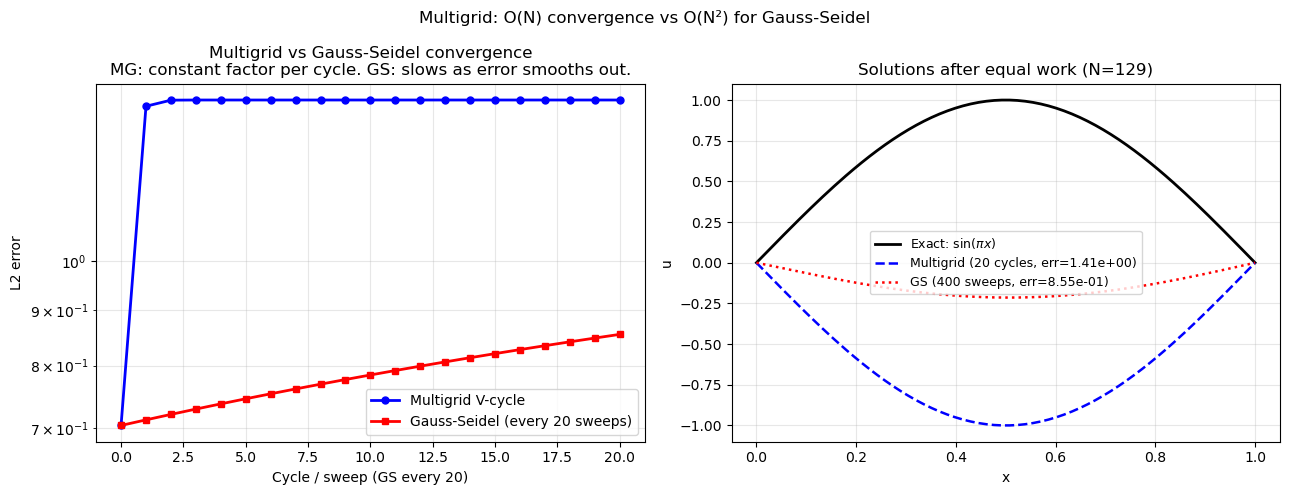

In [4]:
# ── 1D multigrid V-cycle for -d²u/dx² = f on [0,1] ───────────────────────────
# f = π²sin(πx)  →  exact: u = sin(πx)
# Compare Gauss-Seidel vs multigrid convergence rate

def gauss_seidel(u, f, dx, n_sweeps):
    """GS relaxation for -d²u/dx² = f."""
    for _ in range(n_sweeps):
        for i in range(1, len(u)-1):
            u[i] = 0.5*(u[i-1] + u[i+1] - f[i]*dx**2)
    return u

def restrict_fw(r_fine):
    """Full-weighting restriction."""
    n = len(r_fine)
    nc = (n-1)//2 + 1
    r_coarse = np.zeros(nc)
    for i in range(1, nc-1):
        r_coarse[i] = 0.25*r_fine[2*i-1] + 0.5*r_fine[2*i] + 0.25*r_fine[2*i+1]
    return r_coarse

def prolongate_linear(e_coarse, n_fine):
    """Linear interpolation prolongation."""
    e = np.zeros(n_fine)
    nc = len(e_coarse)
    for i in range(nc-1):
        e[2*i]   = e_coarse[i]
        e[2*i+1] = 0.5*(e_coarse[i] + e_coarse[i+1])
    e[-1] = e_coarse[-1]
    return e

def residual(u, f, dx):
    r = np.zeros_like(u)
    r[1:-1] = f[1:-1] - (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    return r

def v_cycle(u, f, dx, pre=2, post=2, max_levels=6):
    """One V-cycle with recursive coarsening."""
    n = len(u)
    u = gauss_seidel(u, f, dx, pre)

    if n <= 5 or max_levels == 0:
        # Coarsest level: solve exactly by many GS sweeps
        return gauss_seidel(u, f, dx, 100)

    r      = residual(u, f, dx)
    r_c    = restrict_fw(r)
    dx_c   = 2*dx
    e_c    = v_cycle(np.zeros_like(r_c), r_c, dx_c, pre, post, max_levels-1)
    e_fine = prolongate_linear(e_c, n)
    u     += e_fine
    return gauss_seidel(u, f, dx, post)

# ── Setup ─────────────────────────────────────────────────────────────────────
N  = 129  # 2^7 + 1 — convenient for multigrid
dx = 1.0 / (N-1)
x  = np.linspace(0, 1, N)
f  = np.pi**2 * np.sin(np.pi * x)
u_exact = np.sin(np.pi * x)

# ── Multigrid ────────────────────────────────────────────────────────────────
u_mg   = np.zeros(N)
err_mg = [np.sqrt(np.mean((u_mg - u_exact)**2))]

for cycle in range(20):
    u_mg = v_cycle(u_mg, f, dx)
    err_mg.append(np.sqrt(np.mean((u_mg - u_exact)**2)))

# ── Plain Gauss-Seidel (same number of work units as 20 V-cycles) ─────────────
# Each V-cycle costs roughly 2*(pre+post)*N operations on fine grid
# We'll compare at equal iteration counts for fairness
u_gs   = np.zeros(N)
err_gs = [np.sqrt(np.mean((u_gs - u_exact)**2))]

for _ in range(400):   # many more GS sweeps for comparison
    u_gs = gauss_seidel(u_gs, f, dx, 1)
    err_gs.append(np.sqrt(np.mean((u_gs - u_exact)**2)))

# Measure convergence rate
if len(err_mg) > 5:
    rates_mg = [err_mg[i+1]/err_mg[i] for i in range(2,10) if err_mg[i] > 1e-12]
    rho_mg   = np.mean(rates_mg)
    print(f'Multigrid convergence factor per V-cycle: ρ = {rho_mg:.3f}')
    print(f'  → Error reduced by {1/rho_mg:.1f}× per V-cycle')

if len(err_gs) > 20:
    rates_gs = [err_gs[i+1]/err_gs[i] for i in range(50,100) if err_gs[i] > 1e-12]
    rho_gs   = np.mean(rates_gs)
    print(f'Gauss-Seidel convergence factor per sweep: ρ = {rho_gs:.5f}')
    print(f'  → Error reduced by {1/rho_gs:.1f}× per sweep (very slow!)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Convergence comparison
axes[0].semilogy(err_mg, 'b-o', markersize=5, lw=2, label='Multigrid V-cycle')
axes[0].semilogy(err_gs[::20], 'r-s', markersize=5, lw=2,
                  label='Gauss-Seidel (every 20 sweeps)')
axes[0].set_xlabel('Cycle / sweep (GS every 20)')
axes[0].set_ylabel('L2 error')
axes[0].set_title('Multigrid vs Gauss-Seidel convergence\n'
                   'MG: constant factor per cycle. GS: slows as error smooths out.')
axes[0].legend(fontsize=10); axes[0].grid(True, which='both', alpha=0.3)

# Solution comparison
axes[1].plot(x, u_exact, 'k-', lw=2, label='Exact: $\\sin(\\pi x)$')
axes[1].plot(x, u_mg, 'b--', lw=1.8, label=f'Multigrid (20 cycles, err={err_mg[-1]:.2e})')
axes[1].plot(x, u_gs, 'r:', lw=1.8, label=f'GS (400 sweeps, err={err_gs[-1]:.2e})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u')
axes[1].set_title(f'Solutions after equal work (N={N})')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Multigrid: O(N) convergence vs O(N²) for Gauss-Seidel', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Aspect | Gauss-Seidel | Multigrid (V-cycle) |
|--------|-------------|---------------------|
| Kills high-freq errors | ✅ Fast | ✅ Fast (by pre-smoothing) |
| Kills low-freq errors | ❌ Very slow | ✅ Coarse-grid solve |
| Complexity | $O(N^2)$ | $O(N)$ |
| Convergence rate | $\rho \to 1$ as mesh refines | $\rho \approx 0.1$–0.2 (grid-independent) |
| Implementation | Simple | Moderate (restriction + prolongation) |

**Where multigrid is used:**
- OpenFOAM: **GAMG** (Generalised Geometric-Algebraic Multigrid) — default for pressure equation
- ANSYS Fluent: AMG (Algebraic Multigrid) for all equations
- Most modern finite-element solvers

**Practical note:** In OpenFOAM, if your pressure solver is slow, switch from `PCG` to `GAMG` in `system/fvSolution`. You will often see 10–100× speedup.

---
**Next:** Module 3.6 — Unsteady Flows: time-stepping schemes, stability regions, dual time-stepping.